In [ ]:
# -*- coding: utf-8 -*-
"""GAN_image_generation_MNIST.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/16OWesReBHqCHK8e1YxTQPnU-ync9AoAX
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# Generator Block
class Generator(nn.Module):
  def __init__(self, z_dim):
    super().__init__()
    self.model = nn.Sequential(
        nn.ConvTranspose2d(z_dim, 256, 7, 1, 0), # Input 1x1, Output 7x7
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.ConvTranspose2d(256, 128, 4, 2, 1), # Input 7x7, Output 14x14
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.ConvTranspose2d(128, 1, 4, 2, 1), # Input 14x14, Output 28x28
        nn.Tanh(),
    )
  def forward(self, x):
      return self.model(x)

In [ ]:
# Discriminator Block
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Conv2d(1, 64, 4, 2, 1),
        nn.LeakyReLU(0.2),
        nn.Conv2d(64, 128, 4, 2, 1),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2),
        nn.Flatten(),
        nn.Linear(128*7*7, 1),
        nn.Sigmoid(),
    )

  def forward(self, x):
      return self.model(x)

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
batch_size = 128
lr = 0.002
z_dim = 100
epochs = 10

In [ ]:
# Dataset loading

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.67MB/s]


In [ ]:
# Initializing loss function, generator, discriminator and optimizers
criterion = nn.BCELoss()
generator = Generator(z_dim).to(device)
discriminator = Discriminator().to(device)
optimizer_g = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

In [ ]:
def show_images(fake):
  img = fake.detach().cpu()[:16]
  grid = img.view(16, 28, 28)

  fig, axes = plt.subplots(4, 4, figsize=(5, 5))
  for i, ax in enumerate(axes.flatten()):
    ax.imshow(grid[i], cmap='gray')
    ax.axis('off')
  plt.show()

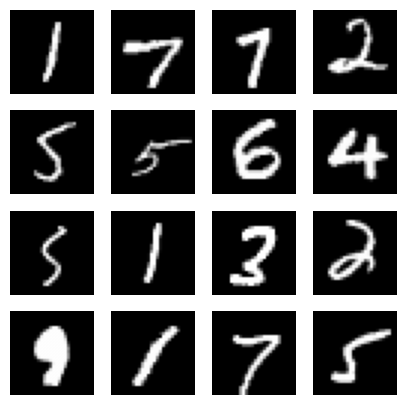

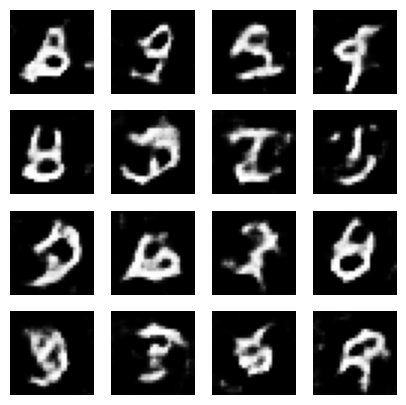

Epoch [0/10], Loss D: 0.9518321752548218, Loss G: 2.1506638526916504


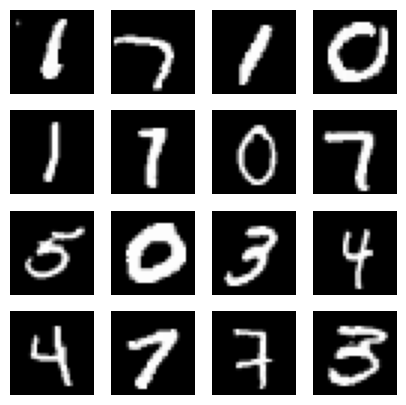

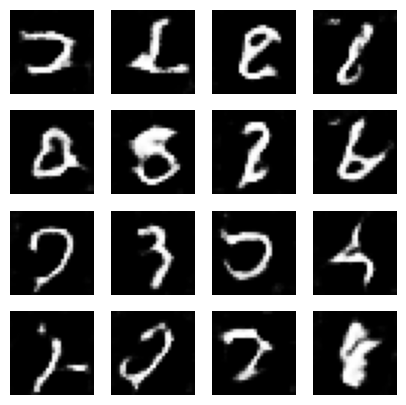

Epoch [1/10], Loss D: 0.9454789161682129, Loss G: 1.3233344554901123


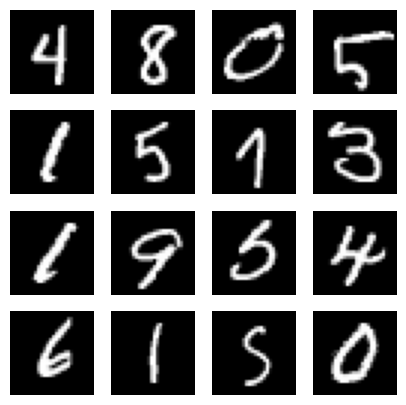

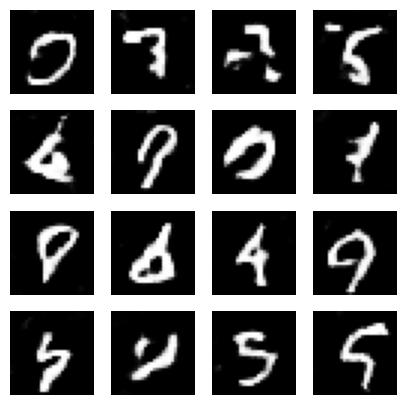

Epoch [2/10], Loss D: 0.5799045562744141, Loss G: 2.4592809677124023


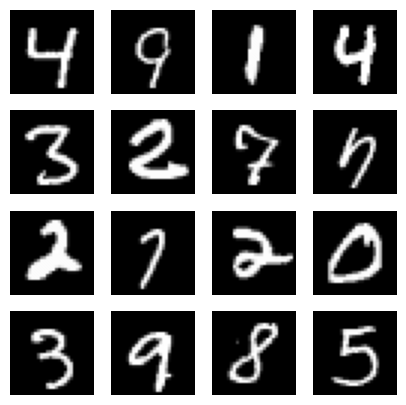

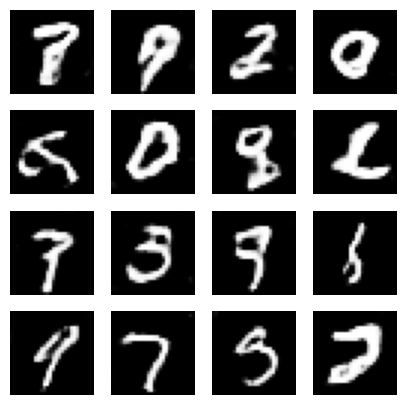

Epoch [3/10], Loss D: 0.8518940210342407, Loss G: 1.7017238140106201


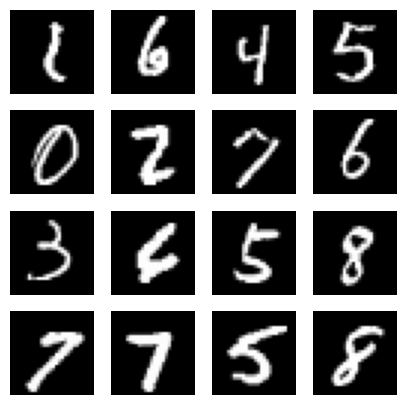

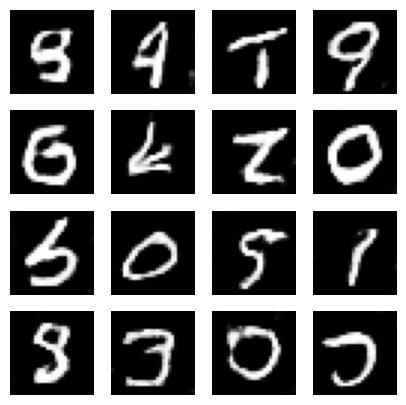

Epoch [4/10], Loss D: 1.6045055389404297, Loss G: 3.4154863357543945


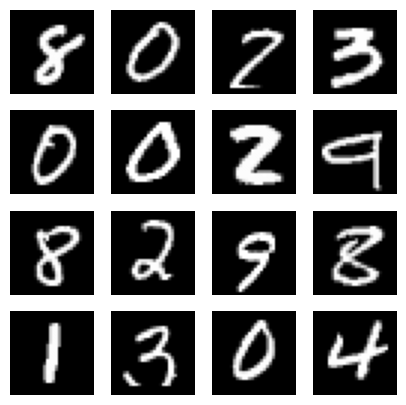

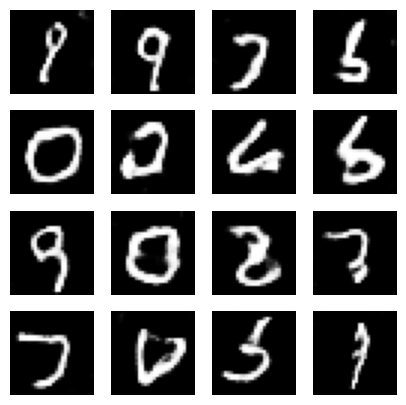

Epoch [5/10], Loss D: 0.6757773160934448, Loss G: 2.6638569831848145


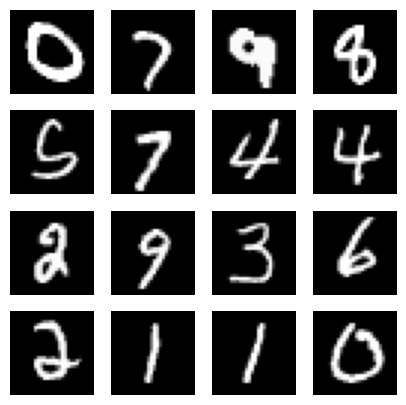

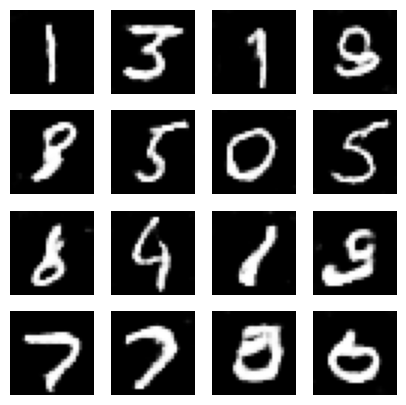

Epoch [6/10], Loss D: 1.197109341621399, Loss G: 2.9691684246063232


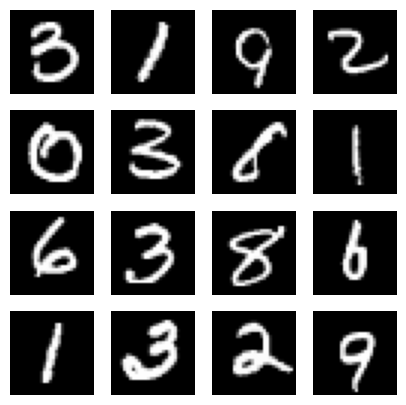

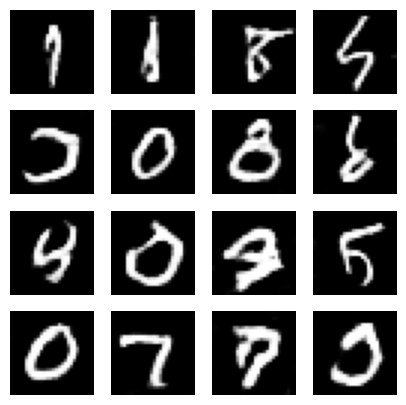

Epoch [7/10], Loss D: 1.0354487895965576, Loss G: 3.8685379028320312


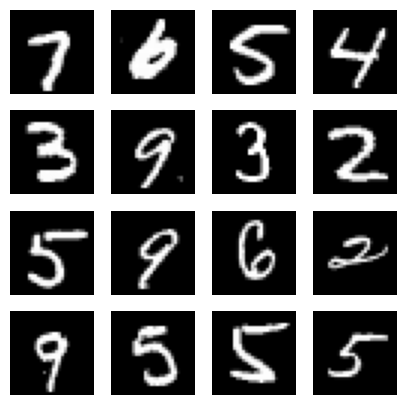

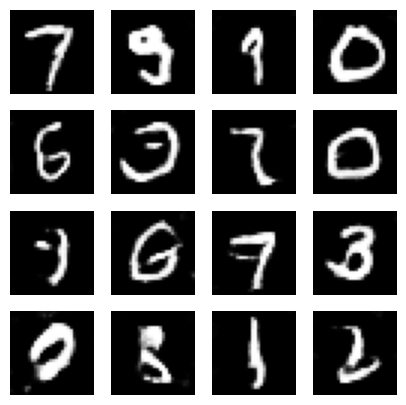

Epoch [8/10], Loss D: 0.6333824396133423, Loss G: 2.047537326812744


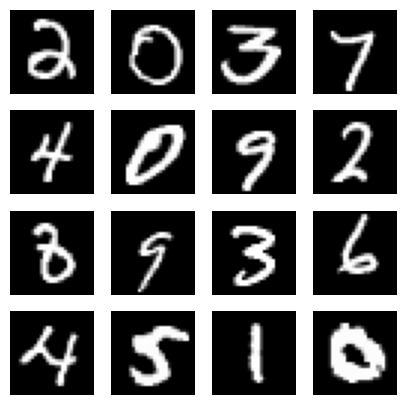

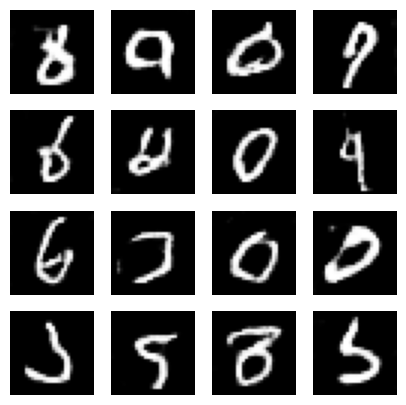

Epoch [9/10], Loss D: 0.7024728655815125, Loss G: 1.7479183673858643


In [ ]:
# Training Step
for epoch in range(epochs):
  for real, _ in dataloader:
    real = real.to(device)
    batch_size = real.size(0)

    # Training discriminator
    noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
    fake = generator(noise)

    real_labels = torch.ones(batch_size, 1).to(device)
    # Label Smoothing
    real_labels = torch.ones(batch_size, 1).to(device) * 0.9

    fake_labels = torch.zeros(batch_size, 1).to(device)

    # Real Loss
    D_real = discriminator(real)
    loss_real = criterion(D_real, real_labels)

    # Fake Loss
    D_fake = discriminator(fake.detach())
    loss_fake = criterion(D_fake, fake_labels)

    # Total Loss
    loss_D = loss_real + loss_fake

    optimizer_d.zero_grad()
    loss_D.backward()
    optimizer_d.step()

    # Train Discriminator
    output = discriminator(fake)
    g_loss = criterion(output, real_labels) # wants Discriminator to think fake is real

    optimizer_g.zero_grad()
    g_loss.backward()
    optimizer_g.step()
  show_images(real)
  show_images(fake)
  print(f"Epoch [{epoch}/{epochs}], Loss D: {loss_D.item()}, Loss G: {g_loss.item()}")

Extension Task for GANS Generate Higher Resolution

Images: Adapt the network architecture to generate higher resolution images than 28x28, perhaps by progressively increasing the output size or using more sophisticated upsampling techniques.

In [ ]:
# Higher Resolution Generator Block (56x56)

class GeneratorHR(nn.Module):
    def __init__(self, z_dim):
        super().__init__()

        self.model = nn.Sequential(

            # Input 1x1, Output 7x7
            nn.ConvTranspose2d(z_dim, 512, 7, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            # Input 7x7, Output 14x14
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # Input 14x14, Output 28x28
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Input 28x28, Output 56x56
            nn.ConvTranspose2d(128, 1, 4, 2, 1),

            # Normalize output to [-1, 1]
            nn.Tanh(),
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# Extension Task
# Higher Resolution Discriminator Block (56x56)

class DiscriminatorHR(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            # Input 56x56, Output 28x28
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            # Input 28x28, Output 14x14
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # Input 14x14, Output 7x7
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Flatten(),

            nn.Linear(256 * 7 * 7, 1),

            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# Dataset loading (56x56 images)

transform_hr = transforms.Compose([
    # Resize original MNIST image from 28x28 to 56x56
    transforms.Resize((56, 56)),

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

dataset_hr = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_hr
)

dataloader_hr = DataLoader(
    dataset_hr,
    batch_size=batch_size,
    shuffle=True
)

In [ ]:

# Initializing loss function, generator, discriminator and optimizers

criterion = nn.BCELoss()

generator_hr = GeneratorHR(z_dim).to(device)

discriminator_hr = DiscriminatorHR().to(device)

optimizer_g_hr = optim.Adam(
    generator_hr.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

optimizer_d_hr = optim.Adam(
    discriminator_hr.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

In [ ]:
# Extension Task
# Function to display 56x56 generated images

def show_hr_images(fake):

    img = fake.detach().cpu()[:16]

    grid = img.view(16, 56, 56)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(grid[i], cmap='gray')
        ax.axis('off')

    plt.show()

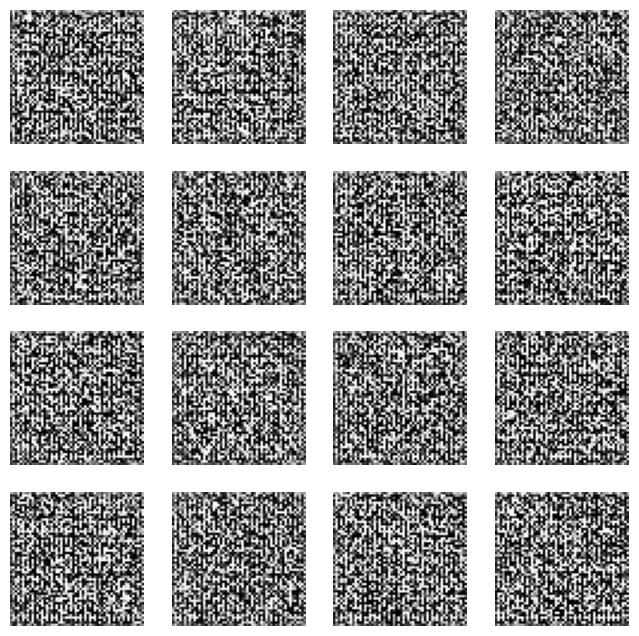

Generated Image Shape: torch.Size([16, 1, 56, 56])


In [ ]:
# Extension Task
# Test Generator Output

noise = torch.randn(16, z_dim, 1, 1).to(device)

fake = generator_hr(noise)

show_hr_images(fake)

print("Generated Image Shape:", fake.shape)

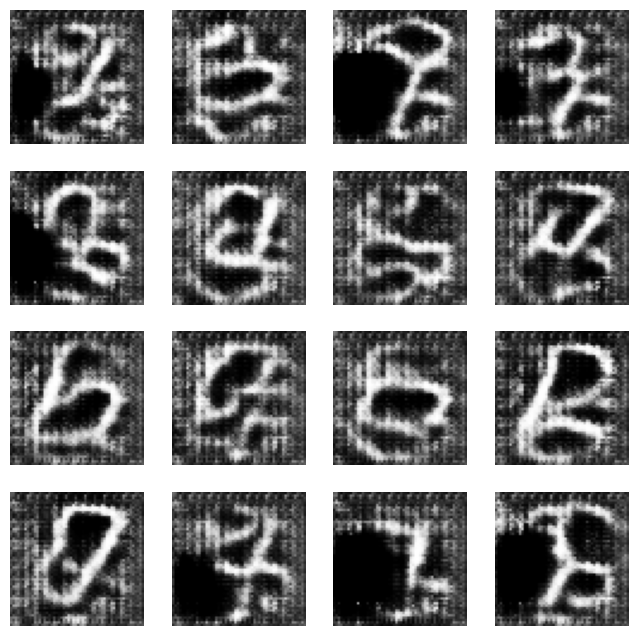

Epoch [0/10], Loss D: 0.3433149456977844, Loss G: 5.17791223526001


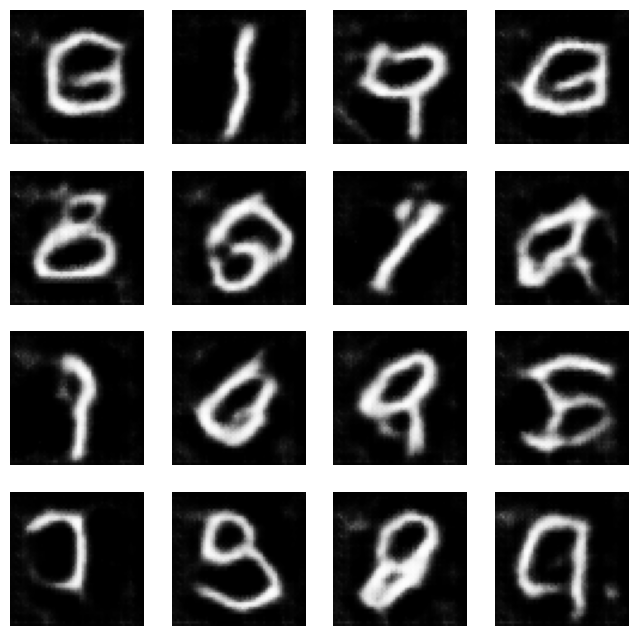

Epoch [1/10], Loss D: 0.45745527744293213, Loss G: 2.4779720306396484


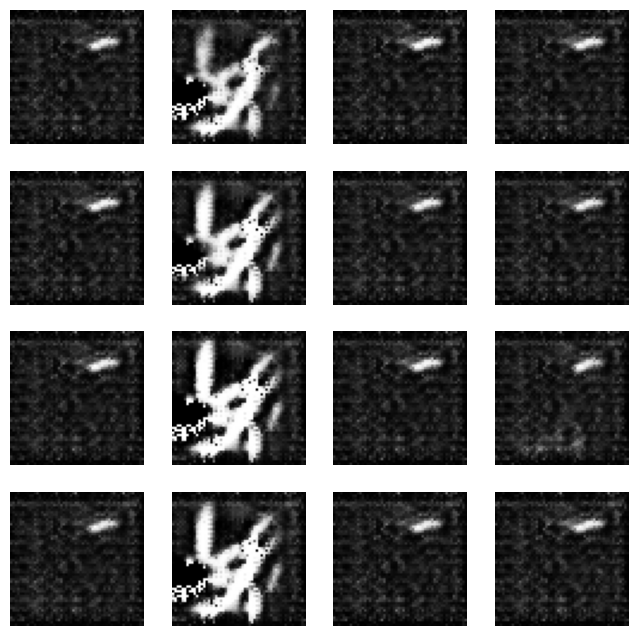

Epoch [2/10], Loss D: 0.33191314339637756, Loss G: 6.110679626464844


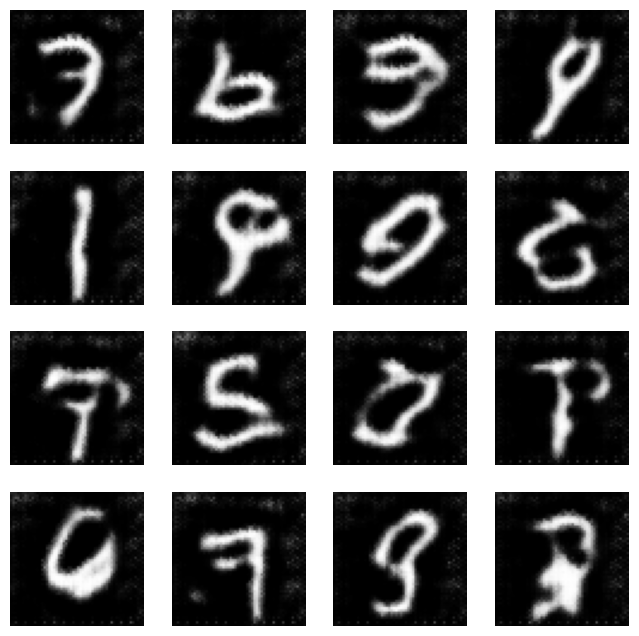

Epoch [3/10], Loss D: 0.3420972228050232, Loss G: 5.893008232116699


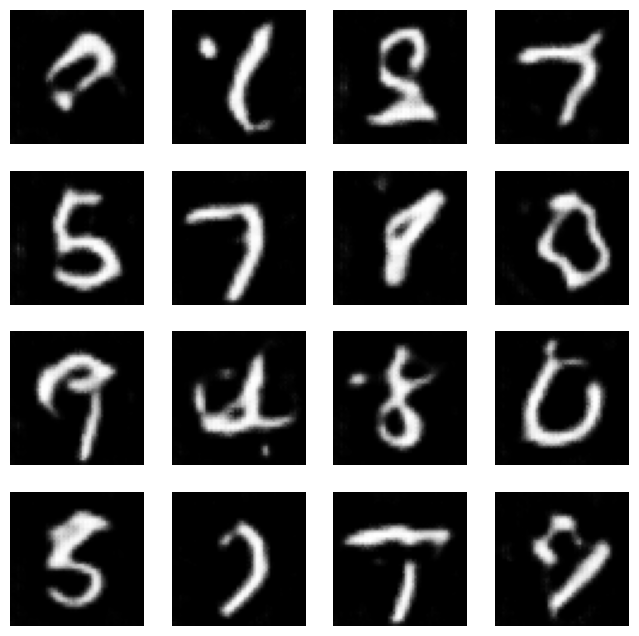

Epoch [4/10], Loss D: 0.34890639781951904, Loss G: 4.516723155975342


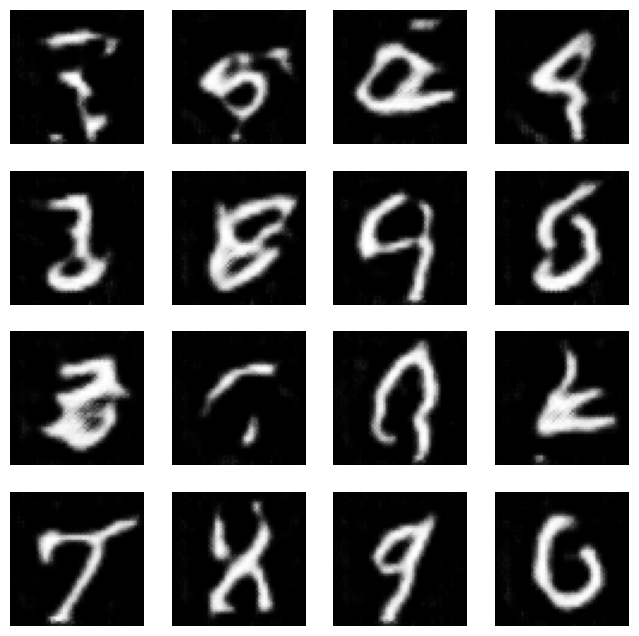

Epoch [5/10], Loss D: 0.7352769374847412, Loss G: 3.016944646835327


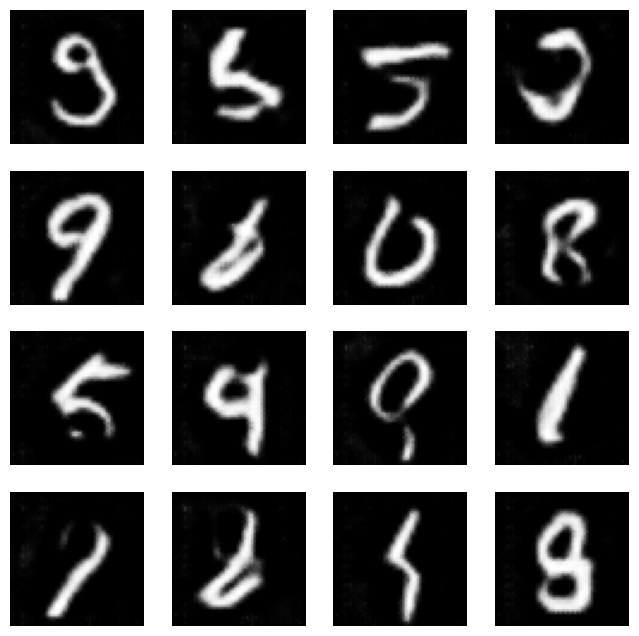

Epoch [6/10], Loss D: 1.4813967943191528, Loss G: 0.40850457549095154


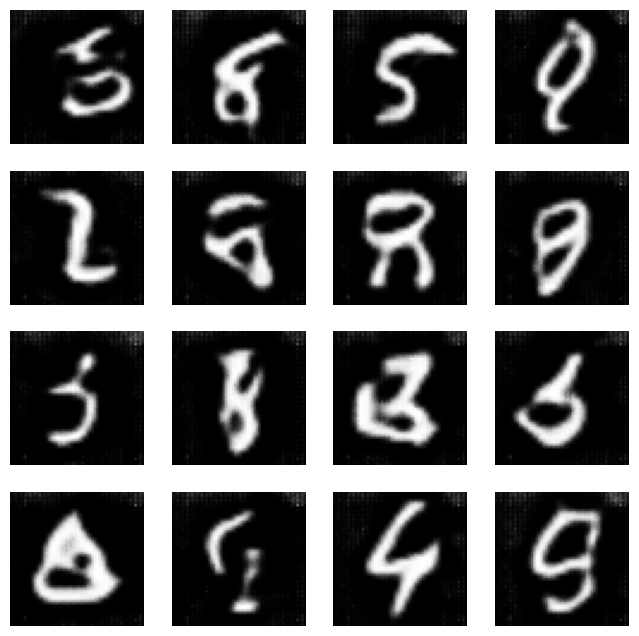

Epoch [7/10], Loss D: 0.3453767001628876, Loss G: 5.153239727020264


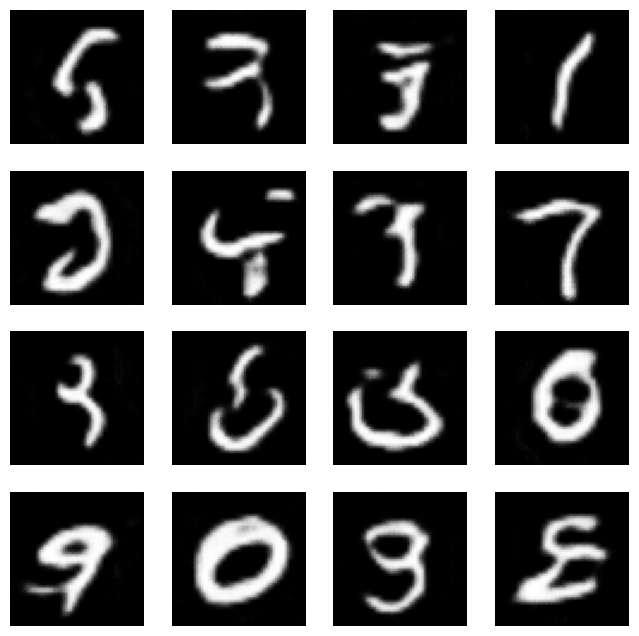

Epoch [8/10], Loss D: 0.8306466341018677, Loss G: 2.0299370288848877


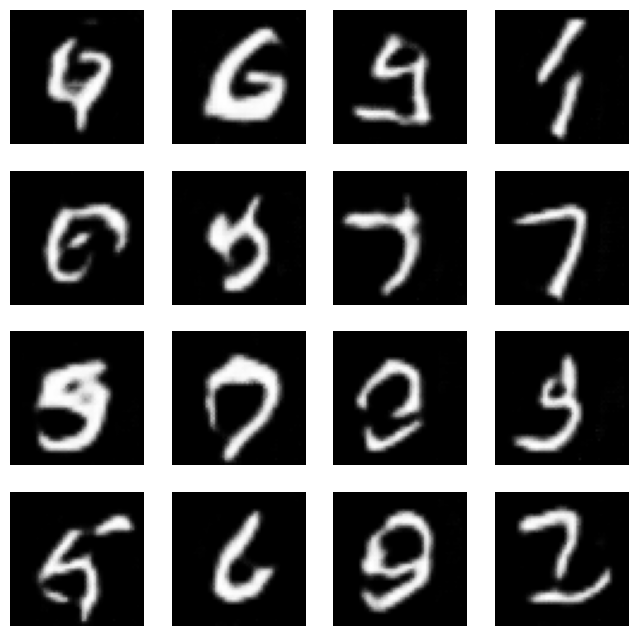

Epoch [9/10], Loss D: 2.6318109035491943, Loss G: 0.44146057963371277


In [ ]:
# Extension Training Step

for epoch in range(epochs):
    for real, _ in dataloader_hr:

        real = real.to(device)
        batch_size = real.size(0)

        # Training discriminator
        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)

        fake = generator_hr(noise)

        real_labels = torch.ones(batch_size, 1).to(device)

        # Label Smoothing
        real_labels = torch.ones(batch_size, 1).to(device) * 0.9

        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Real Loss
        D_real = discriminator_hr(real)
        loss_real = criterion(D_real, real_labels)

        # Fake Loss
        D_fake = discriminator_hr(fake.detach())
        loss_fake = criterion(D_fake, fake_labels)

        # Total Loss
        loss_D = loss_real + loss_fake

        optimizer_d_hr.zero_grad()
        loss_D.backward()
        optimizer_d_hr.step()

        # Train Discriminator
        output = discriminator_hr(fake)

        g_loss = criterion(
            output,
            real_labels
        )  # wants Discriminator to think fake is real

        optimizer_g_hr.zero_grad()
        g_loss.backward()
        optimizer_g_hr.step()

    show_hr_images(fake)

    print(
        f"Epoch [{epoch}/{epochs}], "
        f"Loss D: {loss_D.item()}, "
        f"Loss G: {g_loss.item()}"
    )

In [ ]:
# Extension Task: Generate Higher Resolution Images
#
# Changes Made:
# 1. Added an extra ConvTranspose2d layer in the Generator
#    to increase output size from 28x28 to 56x56.
#
# 2. Added an extra Conv2d layer in the Discriminator
#    to process the larger 56x56 images.
#
# 3. Resized MNIST training images from 28x28 to 56x56
#    using transforms.Resize().
#
# 4. Updated visualization function to display 56x56 images.
#
# Result:
# The GAN now generates higher-resolution handwritten digits
# compared to the original 28x28 implementation.